# Reward Graph Exploration

Explore shortest paths on Cogniland maps using an HP-drain cost graph.

- **Edge cost** = `alpha * hp_drain[terrain(dest)]`, except edges into berry tiles cost **0**
- **`alpha`** scales all costs — lower alpha makes the agent more willing to cross expensive terrain

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../scripts"))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra as scipy_dijkstra

from src.cogniland.envs.tile_effects import TileEffects, drain_for
import scripts.generate_maps as gm

# ── Load maps ──────────────────────────────────────────────────────────────
dataset = torch.load("../data/maps/val.pt", map_location="cpu", weights_only=False)
rgb_all = dataset["rgb"].numpy()        # [N, 128, 128, 3]
heightmap_all = dataset["heightmap"].numpy()  # [N, 128, 128]
tidx_all = dataset["terrain_idx"].numpy()     # [N, 128, 128]  int8, -1 = deadly
berry_all = dataset["berry_mask"].numpy()     # [N, 128, 128]  bool
biomes = dataset["biomes"]

fx = TileEffects()
TERRAIN_NAMES = gm.TERRAIN_NAMES  # 9 terrain classes
HP_DRAIN = np.array([fx.hp_drain[t] for t in TERRAIN_NAMES], dtype=np.float32)

MAP_IDS = [12, 4, 8]  # grassland, archipelago, highland
MAP_SIZE = 128

print(f"Loaded {len(biomes)} val maps, biomes: {biomes}")
print(f"Terrain HP drains: {dict(zip(TERRAIN_NAMES, HP_DRAIN))}")

Loaded 16 val maps, biomes: ['balanced', 'balanced', 'balanced', 'balanced', 'archipelago', 'archipelago', 'archipelago', 'archipelago', 'highland', 'highland', 'highland', 'highland', 'grassland', 'grassland', 'grassland', 'grassland']
Terrain HP drains: {'ocean': np.float32(16.0), 'deep_water': np.float32(10.0), 'water': np.float32(6.0), 'beach': np.float32(1.0), 'sandy': np.float32(1.0), 'grassland': np.float32(1.0), 'forest': np.float32(3.0), 'rocky': np.float32(6.0), 'mountains': np.float32(12.0)}


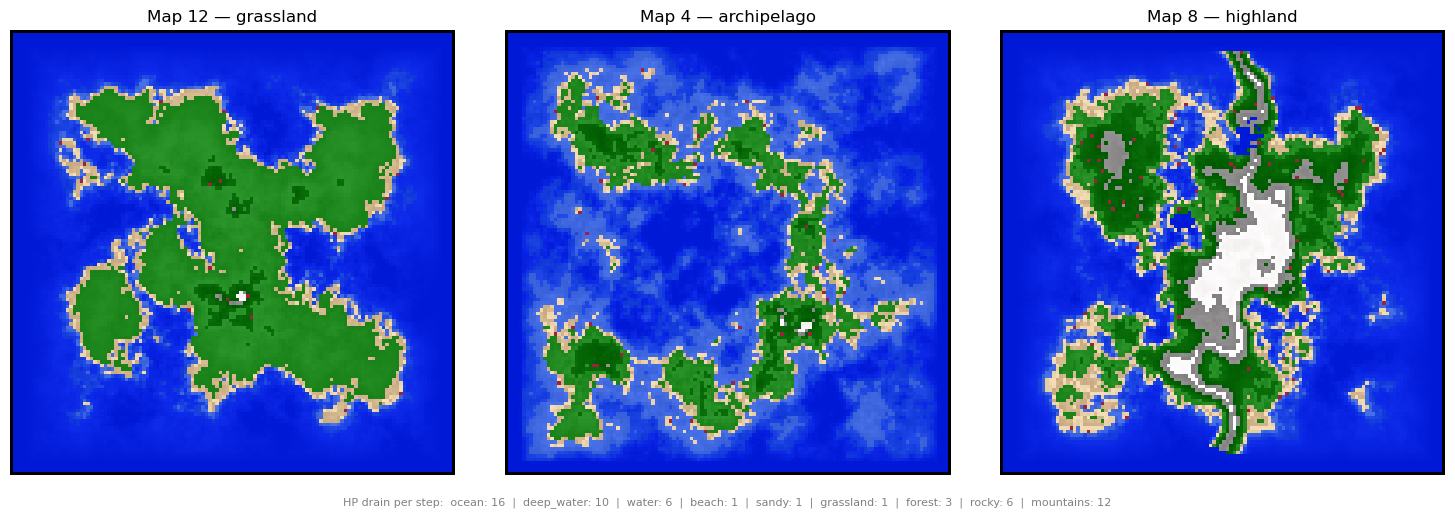

In [12]:
# ── Visualize selected maps ────────────────────────────────────────────────

fig, axes = plt.subplots(1, len(MAP_IDS), figsize=(5 * len(MAP_IDS), 5))
for ax, mid in zip(axes, MAP_IDS):
    ax.imshow(rgb_all[mid])
    ax.set_title(f"Map {mid} — {biomes[mid]}", fontsize=12)
    ax.axis("off")

# Terrain drain legend
drain_text = "  |  ".join(f"{t}: {int(HP_DRAIN[i])}" for i, t in enumerate(TERRAIN_NAMES))
fig.text(0.5, 0.02, f"HP drain per step:  {drain_text}", ha="center", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## HP-drain cost graph

Build a 4-connected grid graph where:
- Edge cost into cell `(r, c)` = `alpha * hp_drain[terrain(r, c)]`
- Edge cost into a **berry tile** = **0** (free healing)
- Deadly border cells (`terrain_idx == -1`) have no edges

`alpha` scales all costs uniformly — play with it to see how the shortest path changes.

In [13]:
def build_drain_graph(tidx: np.ndarray, berry_mask: np.ndarray, alpha: float = 1.0):
    """Build a sparse graph where edge cost = alpha * hp_drain[dest terrain].

    Berry tiles have cost 0 (free healing).
    Deadly cells (tidx == -1) are disconnected.

    Args:
        tidx: int8 [H, W] terrain index per cell (-1 = deadly)
        berry_mask: bool [H, W] berry locations
        alpha: cost multiplier (>0)

    Returns:
        csr_matrix [H*W, H*W] adjacency matrix
    """
    H, W = tidx.shape
    N = H * W

    # Per-cell cost: alpha * drain, but 0 for berries, inf for deadly
    cell_cost = np.full((H, W), np.inf, dtype=np.float64)
    valid = tidx >= 0
    cell_cost[valid] = alpha * HP_DRAIN[tidx[valid]]
    cell_cost[berry_mask & valid] = 0.0

    # Horizontal edges (left-right)
    r_h, c_h = np.mgrid[0:H, 0:W-1]
    src_h = (r_h * W + c_h).ravel()
    dst_h = (r_h * W + c_h + 1).ravel()
    cost_right = cell_cost[r_h, c_h + 1].ravel()  # cost of entering right neighbor
    cost_left = cell_cost[r_h, c_h].ravel()        # cost of entering left neighbor

    # Vertical edges (up-down)
    r_v, c_v = np.mgrid[0:H-1, 0:W]
    src_v = (r_v * W + c_v).ravel()
    dst_v = ((r_v + 1) * W + c_v).ravel()
    cost_down = cell_cost[r_v + 1, c_v].ravel()
    cost_up = cell_cost[r_v, c_v].ravel()

    # Assemble: both directions for each edge pair
    all_src = np.concatenate([src_h, dst_h, src_v, dst_v])
    all_dst = np.concatenate([dst_h, src_h, dst_v, src_v])
    all_cost = np.concatenate([cost_right, cost_left, cost_down, cost_up])

    # Remove infinite edges (deadly cells)
    finite = np.isfinite(all_cost)
    return csr_matrix((all_cost[finite], (all_src[finite], all_dst[finite])), shape=(N, N))


def trace_path(predecessors: np.ndarray, spawn, target, W: int, max_steps: int = 20000):
    """Reconstruct the shortest path using scipy's predecessor array.

    ``predecessors`` comes from ``scipy_dijkstra(graph.T, indices=target_flat,
    return_predecessors=True)``. Each entry ``predecessors[i]`` is the next
    node on the shortest path from ``i`` to ``target`` in the original graph.
    Using this instead of a greedy ctg-gradient descent avoids getting stuck
    when the optimal path crosses berries or flat-cost terrain (ties in ctg).
    """
    spawn_flat = int(spawn[0]) * W + int(spawn[1])
    target_flat = int(target[0]) * W + int(target[1])
    path_flat = [spawn_flat]
    node = spawn_flat
    for _ in range(max_steps):
        if node == target_flat:
            break
        nxt = int(predecessors[node])
        if nxt < 0:
            break
        path_flat.append(nxt)
        node = nxt
    return [(n // W, n % W) for n in path_flat]


def sample_spawn_target(tidx, seed=42, min_manhattan=60):
    """Sample spawn and target on land with minimum Manhattan distance."""
    land = np.argwhere(tidx > 2)  # above water
    rng = np.random.RandomState(seed)
    for _ in range(500):
        i, j = rng.randint(len(land)), rng.randint(len(land))
        s, t = tuple(int(v) for v in land[i]), tuple(int(v) for v in land[j])
        if abs(s[0] - t[0]) + abs(s[1] - t[1]) >= min_manhattan:
            return s, t
    return tuple(int(v) for v in land[0]), tuple(int(v) for v in land[-1])


# Sample spawn/target for each map
spawns, targets = [], []
for mid in MAP_IDS:
    s, t = sample_spawn_target(tidx_all[mid], seed=mid + 100)
    spawns.append(s)
    targets.append(t)
    print(f"Map {mid}: spawn={s} ({TERRAIN_NAMES[tidx_all[mid][s]]}), "
          f"target={t} ({TERRAIN_NAMES[tidx_all[mid][t]]})")

Map 12: spawn=(64, 77) (grassland), target=(22, 33) (grassland)
Map 4: spawn=(17, 26) (sandy), target=(79, 97) (beach)
Map 8: spawn=(83, 51) (forest), target=(17, 70) (grassland)


## Cost-to-go heatmaps for different alpha values

Each row is one map, each column is a different `alpha`. Heatmap shows Dijkstra cost-to-go from every cell to the target. The **cyan contour** marks the `cost = 100` boundary — cells outside it cannot be reached from spawn without losing more HP than the agent has.

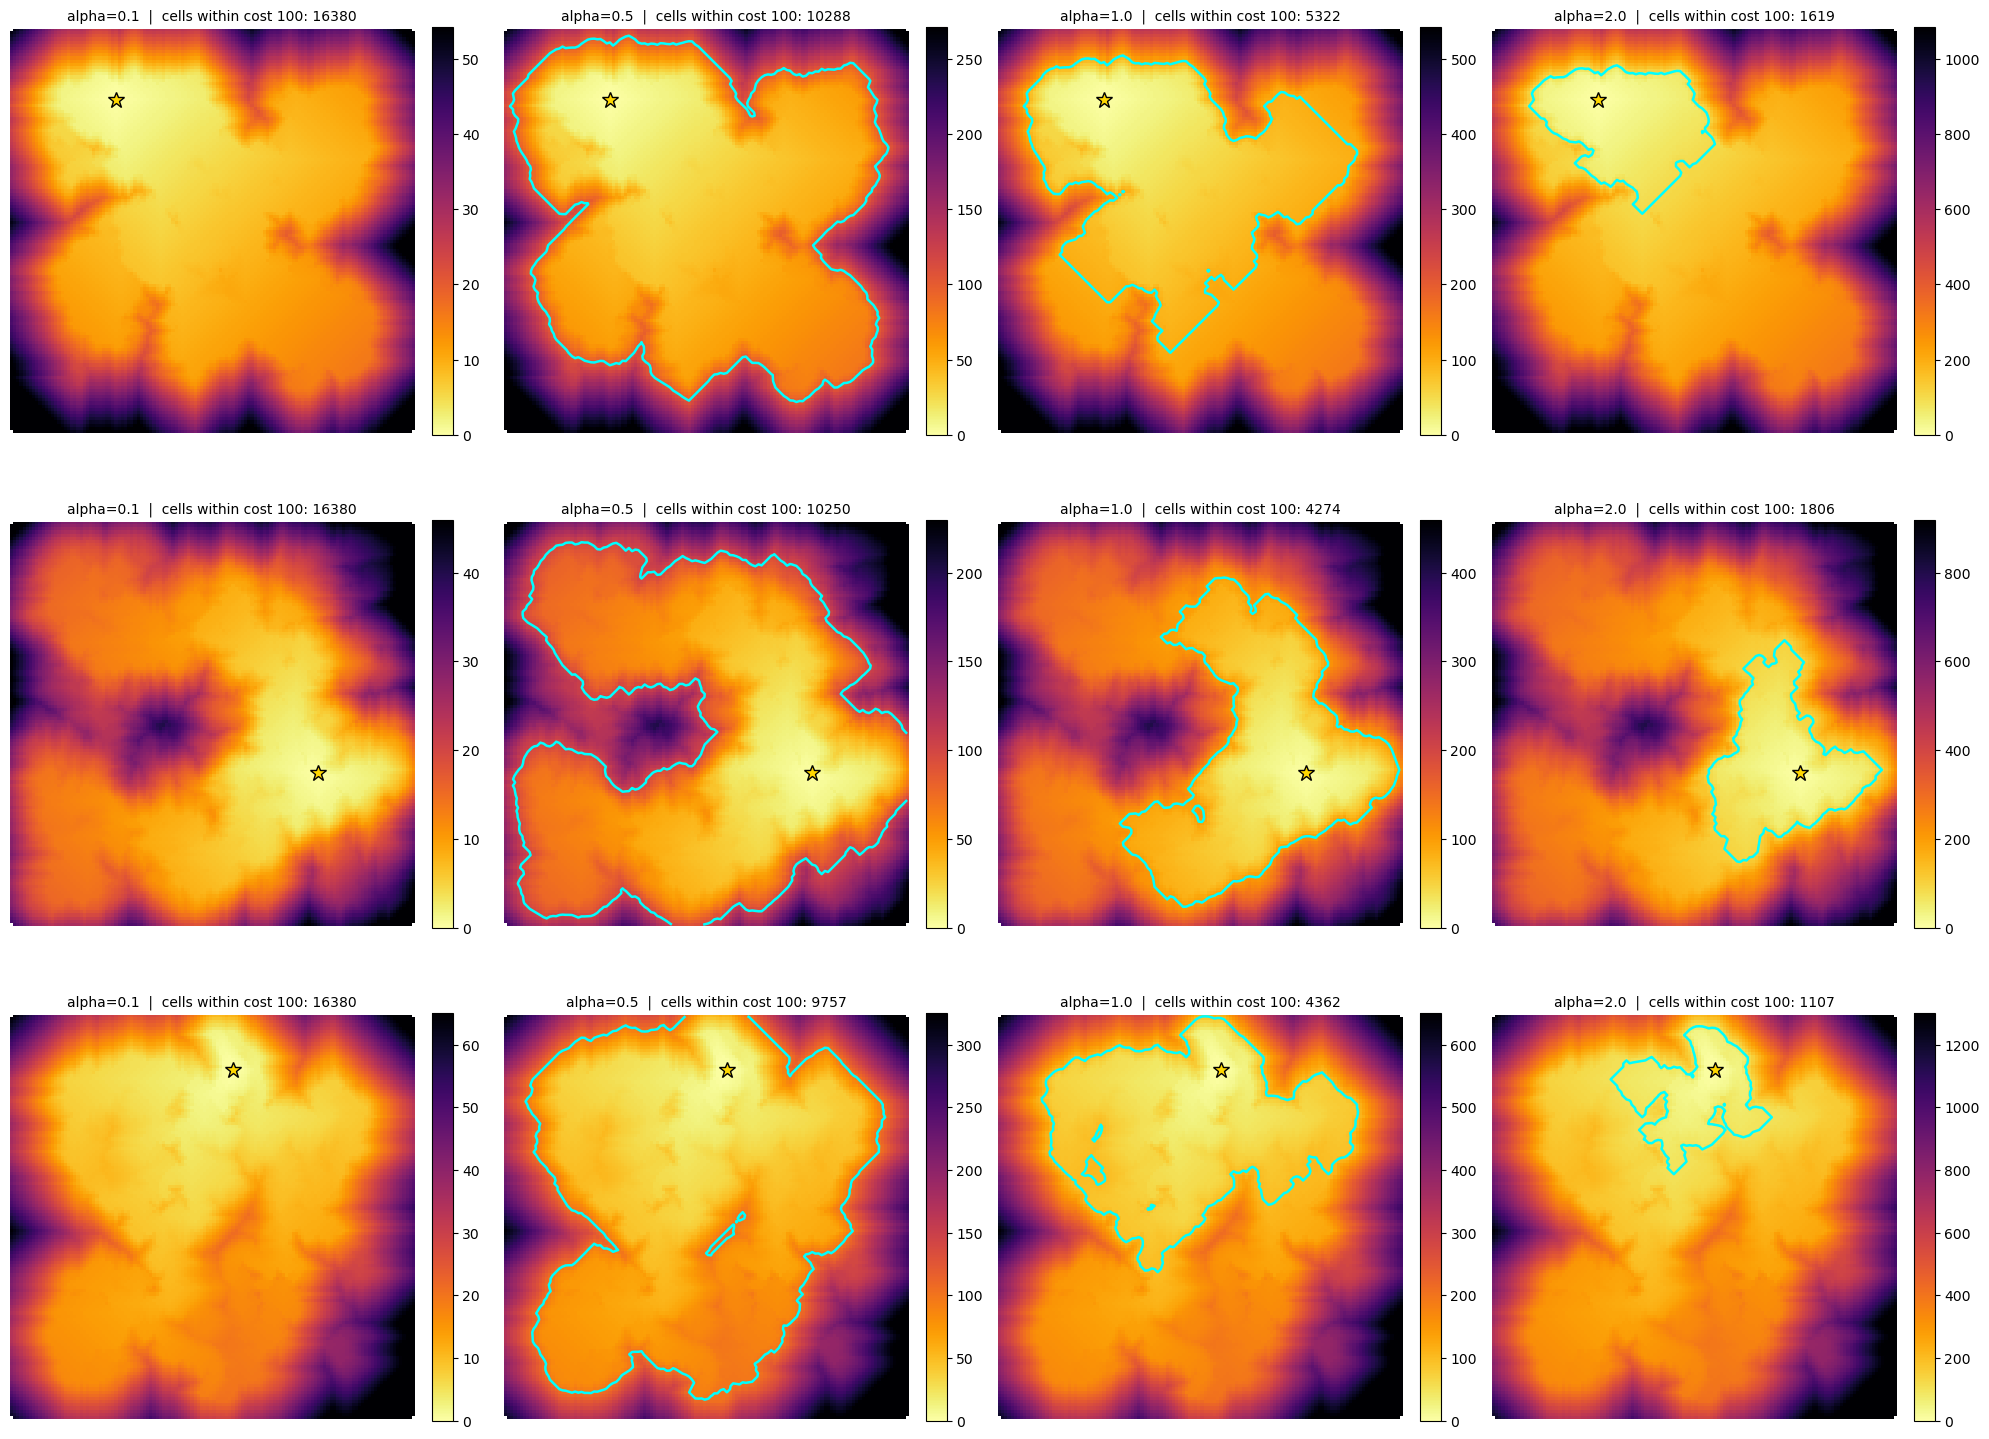

In [14]:
alphas = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(len(MAP_IDS), len(alphas), figsize=(5 * len(alphas), 5 * len(MAP_IDS)))

for row, (mid, target) in enumerate(zip(MAP_IDS, targets)):
    tidx = tidx_all[mid]
    berries = berry_all[mid]
    H, W = tidx.shape

    for col, alpha in enumerate(alphas):
        ax = axes[row, col]

        graph = build_drain_graph(tidx, berries, alpha=alpha)
        target_flat = int(target[0]) * W + int(target[1])
        dist = scipy_dijkstra(graph.T, directed=True, indices=target_flat)
        ctg = dist.reshape(H, W)

        ctg_display = np.where(np.isinf(ctg), np.nan, ctg)
        vmax = np.nanpercentile(ctg_display, 98)
        im = ax.imshow(ctg_display, cmap="inferno_r", origin="upper",
                       vmin=0, vmax=vmax)

        # 100-cost boundary
        if np.nanmax(ctg_display) >= 100:
            ax.contour(ctg_display, levels=[100], colors="cyan",
                       linewidths=1.8, linestyles="-")

        ax.plot(target[1], target[0], "*", color="gold", markersize=12, markeredgecolor="k")
        reachable = int(np.sum(ctg_display <= 100))
        ax.set_title(f"alpha={alpha}  |  cells within cost 100: {reachable}", fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    axes[row, 0].set_ylabel(f"Map {mid}\n{biomes[mid]}", fontsize=11, rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.show()

## Shortest-path trajectories for different alpha values

Each row is one map, each column is a different `alpha`. The red line shows the optimal (minimum HP-cost) path from spawn (green circle) to target (gold star), reconstructed from scipy's predecessor array.

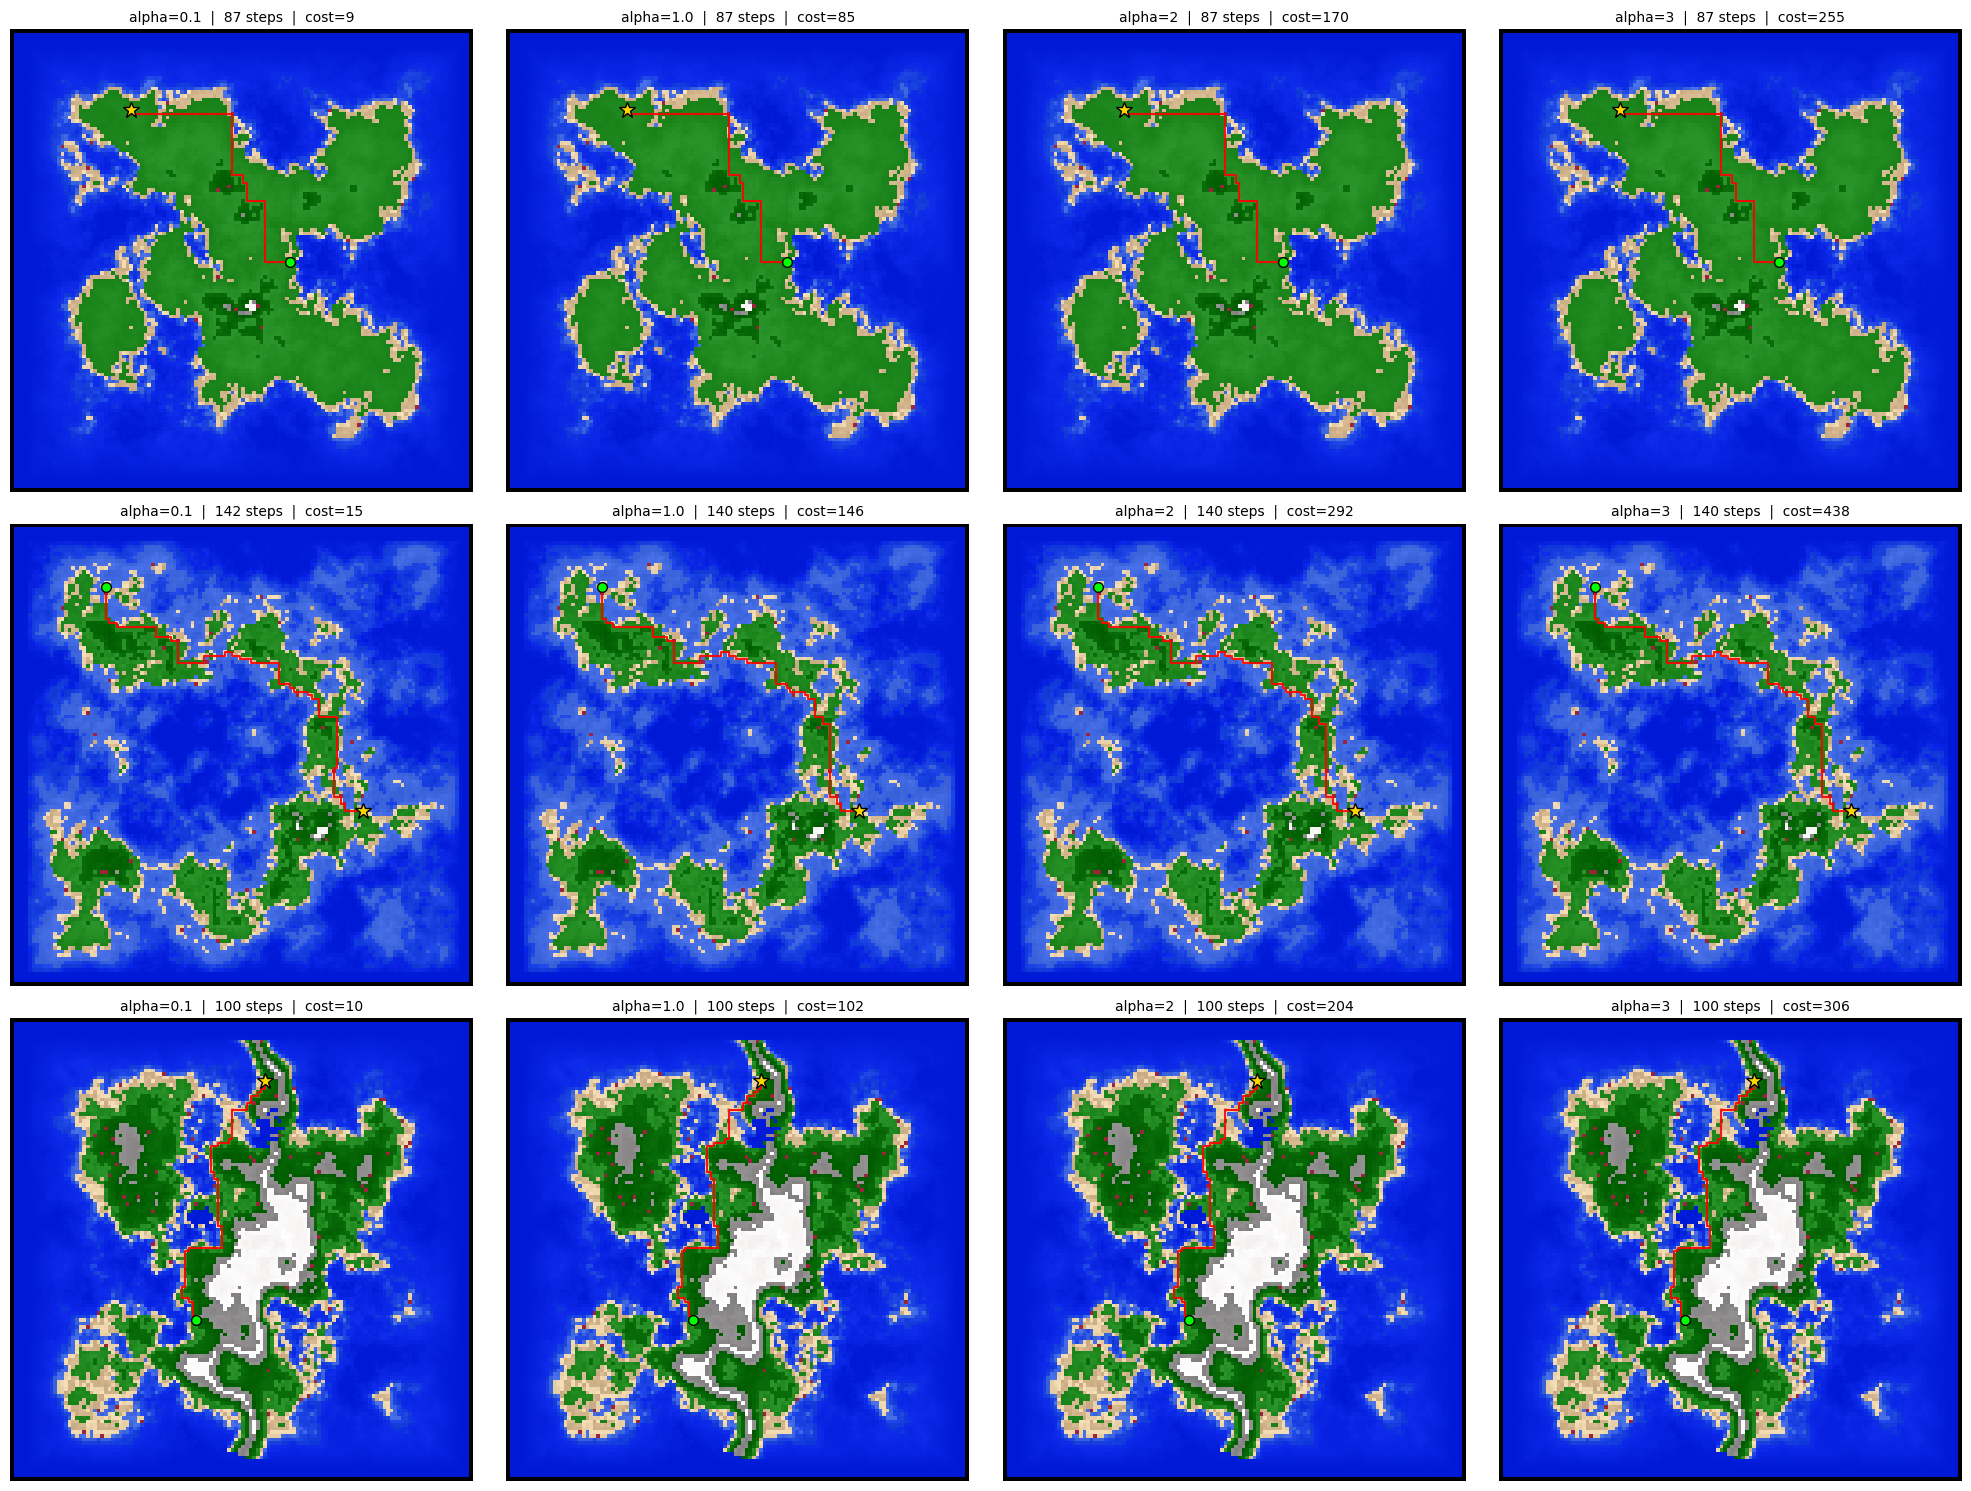

In [17]:
alphas = [0.1, 1.0, 2, 3]

fig, axes = plt.subplots(len(MAP_IDS), len(alphas), figsize=(5 * len(alphas), 5 * len(MAP_IDS)))

for row, (mid, spawn, target) in enumerate(zip(MAP_IDS, spawns, targets)):
    tidx = tidx_all[mid]
    berries = berry_all[mid]
    H, W = tidx.shape

    for col, alpha in enumerate(alphas):
        ax = axes[row, col]

        graph = build_drain_graph(tidx, berries, alpha=alpha)
        target_flat = int(target[0]) * W + int(target[1])
        dist, predecessors = scipy_dijkstra(
            graph.T, directed=True, indices=target_flat, return_predecessors=True
        )
        ctg = dist.reshape(H, W)

        path = trace_path(predecessors, spawn, target, W)
        total_cost = ctg[spawn]

        ax.imshow(rgb_all[mid])
        if len(path) > 1:
            cols = [c for r, c in path]
            rows = [r for r, c in path]
            ax.plot(cols, rows, "r-", linewidth=1.5, alpha=0.9)
        ax.plot(spawn[1], spawn[0], "o", color="lime", markersize=7, markeredgecolor="k")
        ax.plot(target[1], target[0], "*", color="gold", markersize=12, markeredgecolor="k")
        ax.set_title(f"alpha={alpha}  |  {len(path)} steps  |  cost={total_cost:.0f}", fontsize=10)
        ax.axis("off")

    axes[row, 0].set_ylabel(f"Map {mid}\n{biomes[mid]}", fontsize=11, rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.show()